# ServiceNow ITSM Pre-Sales Playbook & Business Case
### Simulated Avant-Vente Cycle — Arvenne Industries SA (Fictional Manufacturing Client)

**Author:** Sherine Marie | **Role target:** Consultant Avant-Vente ServiceNow | **Platform:** Google Colab / Python

---

This notebook simulates a complete pre-sales (avant-vente) cycle for a ServiceNow ITSM opportunity at a fictional mid-size European manufacturer. It contains the four core artefacts a pre-sales consultant produces:

| # | Artefact | Purpose |
|---|----------|---------|
| 1 | **Prospect Discovery Framework** | Qualify the account, map stakeholders, structure discovery calls |
| 2 | **ROI Business Case** | Quantified 3-year value model with NPV, payback, and sensitivity analysis |
| 3 | **Solution Demo Script** | A 45-minute scripted demo mapped to discovered pain points |
| 4 | **Objection-Handling Guide** | Prepared responses to the objections this deal will face |

> ⚠️ *Arvenne Industries SA is entirely fictional. All figures are illustrative assumptions, not ServiceNow pricing or customer data.*

**How to use:** Run all cells (`Runtime → Run all`). Edit the assumptions in Section 2 to re-run the business case for any prospect.

---
# 1. Prospect Discovery Framework

## 1.1 Account Snapshot

**Arvenne Industries SA** — industrial equipment manufacturer, HQ Lyon (France).

| Attribute | Value |
|-----------|-------|
| Revenue | €870M |
| Employees | 4,200 across 7 plants (FR, DE, PL) |
| IT organisation | 85 FTEs; service desk of 22 agents |
| Current ITSM tooling | Aging on-prem GLPI + shared mailboxes + Excel CAB tracker |
| Trigger event | Acquisition of a German competitor (2025) → tool sprawl, two service desks, no unified CMDB |
| Strategic programme | "Usine 2030" — digital factory initiative sponsored by the CEO |
| Budget window | FY27 budget locks in October 2026 |

## 1.2 Why now? (Compelling event)
The acquisition doubled ticket routing complexity, the GLPI server is out of support in 14 months, and unplanned IT-related production-line stoppages cost an estimated €38k/hour. The CIO has been mandated to consolidate IT operations as part of Usine 2030.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

pd.set_option('display.max_colwidth', None)
plt.rcParams.update({'figure.dpi': 100, 'axes.grid': True, 'grid.alpha': 0.3})
print("Environment ready — pandas", pd.__version__)

Environment ready — pandas 2.2.2


## 1.3 Stakeholder Map

Influence/role mapping drives who we demo to, who signs, and who can kill the deal.

In [2]:
stakeholders = pd.DataFrame([
    ["Claire Fontaine", "CIO", "Economic Buyer", "High", "Deliver Usine 2030; consolidate post-acquisition IT", "Visible failure of a flagship programme", "Champion-in-progress — wants board-ready ROI"],
    ["Marc Weber", "IT Operations Director", "Champion", "High", "Reduce firefighting; unify FR/DE operations", "Losing headcount without automation to compensate", "Strong champion — initiated contact at a ServiceNow event"],
    ["Sophie Renard", "Service Desk Manager", "User Buyer", "Medium", "Agent retention; fewer misrouted tickets", "Disruption during migration; agent pushback", "Neutral — fears change fatigue"],
    ["Thomas Krall", "CFO", "Economic Approver", "High", "Cost control post-acquisition; capex discipline", "Multi-year SaaS commitments with soft ROI", "Skeptic — must see payback < 24 months"],
    ["Lukas Brenner", "Plant Ops Director (DE)", "Influencer", "Medium", "Line uptime; fast IT response on shop floor", "IT projects that ignore OT/plant constraints", "Unengaged — needs a plant-floor use case"],
    ["Amira Saidi", "CISO", "Technical Gatekeeper", "Medium", "EU data residency; audit trail; access control", "New SaaS attack surface", "Cautious — requires hosting & compliance answers"],
], columns=["Name", "Role", "Buying Role", "Influence", "Wins (what they want)", "Fears (what blocks them)", "Current stance"])
stakeholders

,Name,Role,Buying Role,Influence,Wins (what they want),Fears (what blocks them),Current stance
0,Claire Fontaine,CIO,Economic Buyer,High,Deliver Usine 2030; consolidate post-acquisition IT,Visible failure of a flagship programme,Champion-in-progress — wants board-ready ROI
1,Marc Weber,IT Operations Director,Champion,High,Reduce firefighting; unify FR/DE operations,Losing headcount without automation to compensate,Strong champion — initiated contact at a ServiceNow event
2,Sophie Renard,Service Desk Manager,User Buyer,Medium,Agent retention; fewer misrouted tickets,Disruption during migration; agent pushback,Neutral — fears change fatigue
3,Thomas Krall,CFO,Economic Approver,High,Cost control post-acquisition; capex discipline,Multi-year SaaS commitments with soft ROI,Skeptic — must see payback < 24 months
4,Lukas Brenner,Plant Ops Director (DE),Influencer,Medium,Line uptime; fast IT response on shop floor,IT projects that ignore OT/plant constraints,Unengaged — needs a plant-floor use case
5,Amira Saidi,CISO,Technical Gatekeeper,Medium,EU data residency; audit trail; access control,New SaaS attack surface,Cautious — requires hosting & compliance answers


## 1.4 Discovery Question Bank

Organised by theme, moving from **situation → pain → impact → payoff** (SPIN). Use open questions first; quantify everything that can feed the business case in Section 2.

### A. Current state & landscape
1. Walk me through what happens today when an employee at the Stuttgart plant has an IT issue — from report to resolution.
2. How are the French and German service desks organised since the acquisition? Where do tickets get handed off?
3. What does your CMDB or asset inventory look like today? How confident are you in it?
4. Which processes are formalised (ITIL or otherwise) and which live in people's heads?

### B. Incident & request management (quantify!)
5. How many incidents and service requests do you handle monthly? What's the trend since the acquisition?
6. What is your average resolution time (MTTR)? Your first-call resolution rate?
7. What share of tickets are misrouted or bounced between teams? What does a bounce cost in delay?
8. How do plant-floor incidents get prioritised against office IT issues?

### C. Self-service & employee experience
9. What can employees resolve today without contacting the service desk?
10. What are your top 10 ticket categories? Which are repetitive enough to automate or deflect?
11. How do new joiners get equipment and access? How long does onboarding take end-to-end?

### D. Change, problem & risk
12. Tell me about your last change-related outage. What did it cost?
13. How does CAB work today? How long does a normal change wait for approval?
14. How do you currently meet audit requirements for change traceability?

### E. Cost & strategic alignment
15. What does the service desk cost annually (people, tools, licenses)?
16. What is the cost of an hour of unplanned line stoppage attributable to IT?
17. How does IT service consolidation map to the Usine 2030 milestones the CEO reports to the board?
18. If we did nothing for 18 months, what happens?

### F. Decision process & qualification
19. Who needs to say yes — and who can say no? What does the CFO need to see?
20. What's the budget process and timeline for FY27? What other initiatives compete for this budget?

## 1.5 Qualification Scorecard (MEDDPICC)

Score each dimension 0–2 after every interaction. Anything ≤ 1 is an action item, not a fact of life.

In [3]:
meddpicc = pd.DataFrame([
    ["Metrics", 2, "MTTR, ticket volume, €38k/h stoppage cost identified and quantifiable"],
    ["Economic Buyer", 1, "CIO engaged; CFO not yet met — schedule business-case review with Thomas Krall"],
    ["Decision Criteria", 1, "Formal criteria undefined; opportunity to shape them around consolidation + ROI"],
    ["Decision Process", 1, "FY27 budget locks October 2026; full process unmapped"],
    ["Paper Process", 0, "Procurement & legal route unknown — ask Claire's PMO"],
    ["Identified Pain", 2, "Tool sprawl, GLPI end-of-support, misrouting, production stoppage exposure"],
    ["Champion", 2, "Marc Weber actively selling internally; equip him with the exec summary"],
    ["Competition", 1, "Status quo (GLPI upgrade) + likely Jira Service Management counter-bid"],
], columns=["Dimension", "Score (0-2)", "Evidence / Next action"])

total = meddpicc["Score (0-2)"].sum()
print(f"Qualification score: {total}/16 — {'Strong, pursue' if total >= 12 else 'Pursue with gap plan' if total >= 8 else 'At risk — fix gaps before investing'}")
meddpicc

Qualification score: 10/16 — Pursue with gap plan


,Dimension,Score (0-2),Evidence / Next action
0,Metrics,2,"MTTR, ticket volume, €38k/h stoppage cost identified and quantifiable"
1,Economic Buyer,1,CIO engaged; CFO not yet met — schedule business-case review with Thomas Krall
2,Decision Criteria,1,Formal criteria undefined; opportunity to shape them around consolidation + ROI
3,Decision Process,1,FY27 budget locks October 2026; full process unmapped
4,Paper Process,0,Procurement & legal route unknown — ask Claire's PMO
5,Identified Pain,2,"Tool sprawl, GLPI end-of-support, misrouting, production stoppage exposure"
6,Champion,2,Marc Weber actively selling internally; equip him with the exec summary
7,Competition,1,Status quo (GLPI upgrade) + likely Jira Service Management counter-bid


## 1.6 Pain-Point Capture Matrix

Each pain discovered is logged with severity and its link to the value model — this is the bridge between discovery and the ROI case.

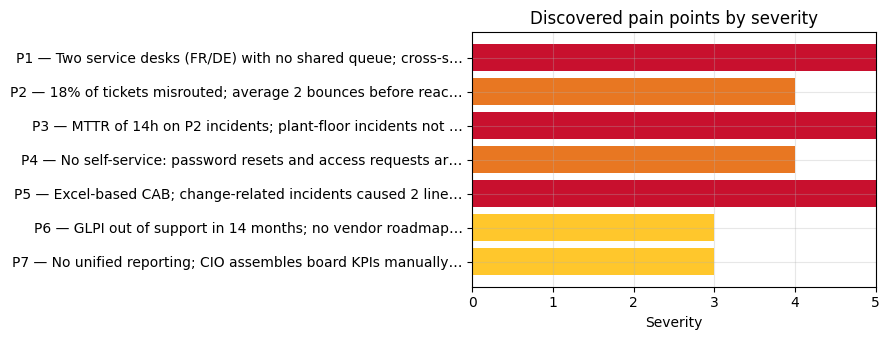

,ID,Pain (verbatim from discovery),Owner(s),Severity (1-5),Feeds business-case lever
0,P1,Two service desks (FR/DE) with no shared queue; cross-site tickets re-entered manually,"Sophie, Marc",5,Consolidation savings + misrouting reduction
1,P2,18% of tickets misrouted; average 2 bounces before reaching the right team,Sophie,4,Auto-routing / reduced handle time
2,P3,MTTR of 14h on P2 incidents; plant-floor incidents not prioritised,"Lukas, Marc",5,MTTR reduction + downtime avoidance
3,P4,No self-service: password resets and access requests are 31% of volume,Sophie,4,Self-service deflection
4,P5,Excel-based CAB; change-related incidents caused 2 line stoppages last year,"Marc, Lukas",5,Change failure & downtime reduction
5,P6,GLPI out of support in 14 months; no vendor roadmap,"Claire, Amira",3,Risk avoidance (qualitative)
6,P7,No unified reporting; CIO assembles board KPIs manually each month,Claire,3,Productivity (qualitative)


In [4]:
pains = pd.DataFrame([
    ["P1", "Two service desks (FR/DE) with no shared queue; cross-site tickets re-entered manually", "Sophie, Marc", 5, "Consolidation savings + misrouting reduction"],
    ["P2", "18% of tickets misrouted; average 2 bounces before reaching the right team", "Sophie", 4, "Auto-routing / reduced handle time"],
    ["P3", "MTTR of 14h on P2 incidents; plant-floor incidents not prioritised", "Lukas, Marc", 5, "MTTR reduction + downtime avoidance"],
    ["P4", "No self-service: password resets and access requests are 31% of volume", "Sophie", 4, "Self-service deflection"],
    ["P5", "Excel-based CAB; change-related incidents caused 2 line stoppages last year", "Marc, Lukas", 5, "Change failure & downtime reduction"],
    ["P6", "GLPI out of support in 14 months; no vendor roadmap", "Claire, Amira", 3, "Risk avoidance (qualitative)"],
    ["P7", "No unified reporting; CIO assembles board KPIs manually each month", "Claire", 3, "Productivity (qualitative)"],
], columns=["ID", "Pain (verbatim from discovery)", "Owner(s)", "Severity (1-5)", "Feeds business-case lever"])

fig, ax = plt.subplots(figsize=(9, 3.5))
colors = ['#C8102E' if s == 5 else '#E87722' if s == 4 else '#FFC72C' for s in pains['Severity (1-5)']]
ax.barh(pains['ID'] + " — " + pains['Pain (verbatim from discovery)'].str[:55] + "…", pains['Severity (1-5)'], color=colors)
ax.set_xlabel("Severity"); ax.set_xlim(0, 5); ax.invert_yaxis()
ax.set_title("Discovered pain points by severity")
plt.tight_layout(); plt.show()
pains

---
# 2. ROI Business Case — 3-Year Value Model

The model compares **current state** (GLPI + manual processes, post-acquisition sprawl) against **future state** (ServiceNow ITSM) over 3 years.

**Value levers** (each traced to a discovered pain):

| Lever | Pain | Mechanism |
|-------|------|-----------|
| Self-service deflection | P4 | Portal + Virtual Agent deflect password/access/how-to tickets |
| Handling efficiency | P1, P2 | Auto-routing, single queue, agent workspace cut handle time & bounces |
| MTTR reduction → downtime avoidance | P3, P5 | Faster restore on plant-impacting incidents; fewer failed changes |
| Tool & infrastructure consolidation | P6 | Retire GLPI servers, second desk tooling, spreadsheet workarounds |

All assumptions are editable — change them and re-run.

In [5]:
# ============ ASSUMPTIONS — edit these for any prospect ============
A = dict(
    # --- Current-state volume & cost ---
    incidents_per_month      = 6800,
    requests_per_month       = 1900,
    cost_per_ticket          = 19.0,    # € fully-loaded average handling cost
    deflectable_share        = 0.31,    # share of volume that is password/access/how-to (P4)
    misrouted_share          = 0.18,    # P2
    misroute_extra_cost      = 11.0,    # € extra handling per misrouted ticket

    # --- Downtime exposure (P3, P5) ---
    it_downtime_hours_year   = 86,      # plant hours/year lost to IT-attributable incidents & failed changes
    downtime_cost_per_hour   = 38000,   # € (CFO-validated figure from discovery)

    # --- Tooling being retired (P6) ---
    legacy_tooling_cost_year = 145000,  # GLPI infra+support, DE desk tool, misc licenses

    # --- Improvement trajectory with ServiceNow (ramped Y1→Y3) ---
    deflection_rate          = [0.40, 0.60, 0.75],  # of deflectable volume, via portal + Virtual Agent
    handle_time_reduction    = [0.10, 0.18, 0.22],  # on remaining tickets (auto-routing, workspace, AI assist)
    misroute_reduction       = [0.60, 0.80, 0.85],
    downtime_reduction       = [0.20, 0.35, 0.45],  # faster MTTR + safer change
    tooling_retirement       = [0.30, 1.00, 1.00],  # GLPI retired end of Y1

    # --- ServiceNow investment (illustrative, NOT vendor pricing) ---
    licenses_year            = [310000, 310000, 325000],  # ITSM Pro, ~fulfiller-based
    implementation_one_off   = 280000,  # partner-led implementation, Y1
    training_change_mgmt     = 60000,   # Y1
    internal_effort          = [90000, 35000, 35000],     # internal project FTE cost
    platform_admin           = [0, 70000, 70000],         # 1 platform owner from Y2

    discount_rate            = 0.08,
    year1_realization        = 0.50,   # 6-month phased go-live: Y1 captures ~half the run-rate
)
print("Assumptions loaded.")

Assumptions loaded.


In [10]:
# ============ MODEL ============
years = [1, 2, 3]
tickets_year = (A['incidents_per_month'] + A['requests_per_month']) * 12
deflectable  = tickets_year * A['deflectable_share']

rows = []
for i, y in enumerate(years):
    # Benefits
    b_deflect  = deflectable * A['deflection_rate'][i] * A['cost_per_ticket']
    remaining  = tickets_year - deflectable * A['deflection_rate'][i]
    b_handle   = remaining * A['cost_per_ticket'] * A['handle_time_reduction'][i]
    b_misroute = tickets_year * A['misrouted_share'] * A['misroute_reduction'][i] * A['misroute_extra_cost']
    b_downtime = A['it_downtime_hours_year'] * A['downtime_reduction'][i] * A['downtime_cost_per_hour']
    b_tooling  = A['legacy_tooling_cost_year'] * A['tooling_retirement'][i]
    ramp = A['year1_realization'] if y == 1 else 1.0
    b_deflect, b_handle, b_misroute, b_downtime = (x * ramp for x in (b_deflect, b_handle, b_misroute, b_downtime))
    benefits = b_deflect + b_handle + b_misroute + b_downtime + b_tooling

    # Costs
    costs = (A['licenses_year'][i] + A['internal_effort'][i] + A['platform_admin'][i]
             + (A['implementation_one_off'] + A['training_change_mgmt'] if y == 1 else 0))

    rows.append([y, b_deflect, b_handle, b_misroute, b_downtime, b_tooling, benefits, costs, benefits - costs])

df = pd.DataFrame(rows, columns=["Year", "Self-service deflection", "Handling efficiency",
                                 "Misrouting eliminated", "Downtime avoided", "Tooling retired",
                                 "Total benefits", "Total costs", "Net cash flow"])

# Financial metrics
df["Cumulative net"] = df["Net cash flow"].cumsum()
npv = sum(df["Net cash flow"][i] / (1 + A['discount_rate'])**(i+1) for i in range(3))
total_b, total_c = df["Total benefits"].sum(), df["Total costs"].sum()
roi = (total_b - total_c) / total_c

# Payback — monthly cash curve: one-off costs hit month 0, run-rate spread monthly
oneoff = A['implementation_one_off'] + A['training_change_mgmt']
monthly_net = []
for i in range(3):
    recurring = df["Total costs"][i] - (oneoff if i == 0 else 0)
    monthly_net += [(df["Total benefits"][i] - recurring) / 12] * 12
cum_monthly = np.concatenate([[-oneoff], -oneoff + np.cumsum(monthly_net)])
payback_month = next((m for m, v in enumerate(cum_monthly) if v >= 0), None)

summary = pd.DataFrame({
    "Metric": ["3-year total benefits", "3-year total costs", "3-year net value",
               f"NPV @ {A['discount_rate']:.0%}", "ROI (3-year)", "Payback"],
    "Value": [f"€{total_b:,.0f}", f"€{total_c:,.0f}", f"€{total_b-total_c:,.0f}",
              f"€{npv:,.0f}", f"{roi:.0%}", f"{payback_month:.0f} months"]
})
display(summary)
df.round(0)

,Metric,Value
0,3-year total benefits,"€5,343,358"
1,3-year total costs,"€1,585,000"
2,3-year net value,"€3,758,358"
3,NPV @ 8%,"€3,078,466"
4,ROI (3-year),237%
5,Payback,13 months


,Year,Self-service deflection,Handling efficiency,Misrouting eliminated,Downtime avoided,Tooling retired,Total benefits,Total costs,Net cash flow,Cumulative net
0,1,122983.0,86882.0,62014.0,326800.0,43500.0,642178.0,740000,-97822.0,-97822.0
1,2,368950.0,290637.0,165370.0,1143800.0,145000.0,2113756.0,415000,1698756.0,1600935.0
2,3,461187.0,334931.0,175705.0,1470600.0,145000.0,2587423.0,430000,2157423.0,3758358.0


## 2.1 Where the value comes from

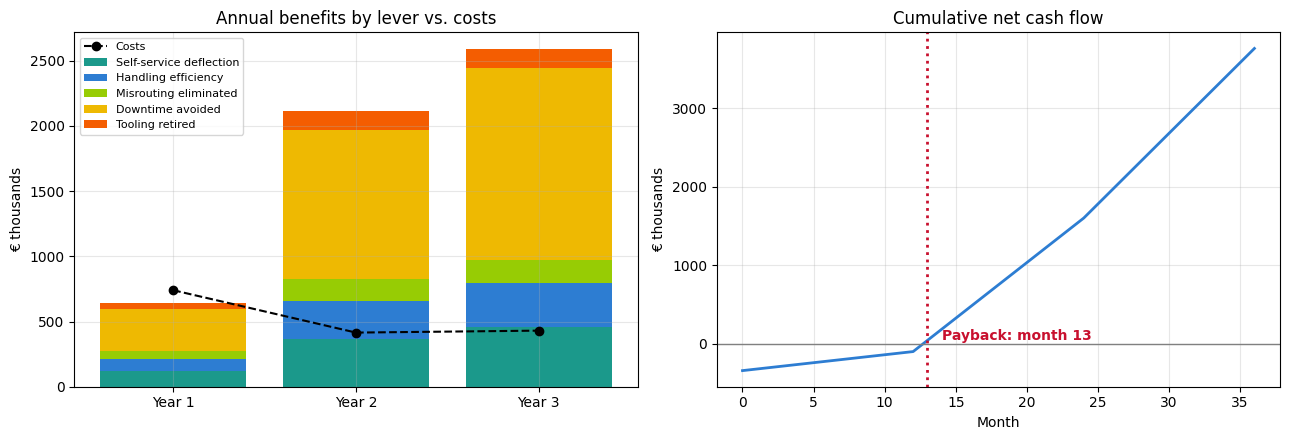

In [11]:
years = df["Year"].tolist()   # re-derived so this cell survives out-of-order runs
levers = ["Self-service deflection", "Handling efficiency", "Misrouting eliminated", "Downtime avoided", "Tooling retired"]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Stacked benefits by year
bottom = np.zeros(3)
palette = ['#1B998B', '#2D7DD2', '#97CC04', '#EEB902', '#F45D01']
for lever, c in zip(levers, palette):
    axes[0].bar([f"Year {y}" for y in years], df[lever]/1000, bottom=bottom, label=lever, color=c)
    bottom += df[lever].values/1000
axes[0].plot([f"Year {y}" for y in years], df["Total costs"]/1000, 'k--o', label="Costs")
axes[0].set_ylabel("€ thousands"); axes[0].set_title("Annual benefits by lever vs. costs")
axes[0].legend(fontsize=8)

# Cumulative cash flow + payback (one-off costs at month 0)
months = np.arange(0, 37)
axes[1].plot(months, cum_monthly/1000, color='#2D7DD2', lw=2)
axes[1].axhline(0, color='grey', lw=1)
if payback_month:
    axes[1].axvline(payback_month, color='#C8102E', ls=':', lw=2)
    axes[1].annotate(f"Payback: month {payback_month:.0f}", (payback_month+1, 50), color='#C8102E', fontweight='bold')
axes[1].set_xlabel("Month"); axes[1].set_ylabel("€ thousands")
axes[1].set_title("Cumulative net cash flow")
plt.tight_layout(); plt.show()

## 2.2 Sensitivity Analysis

The CFO (Thomas Krall) will challenge the assumptions. The tornado chart shows the 3-year net value when each key driver moves ±25% — proving the case holds even under pessimistic assumptions.

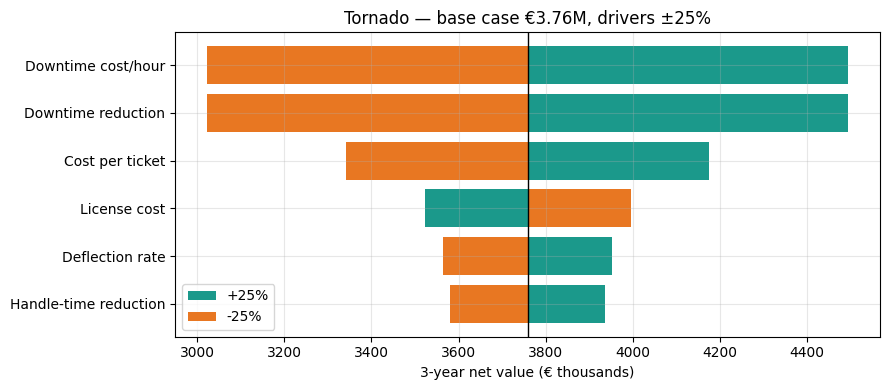

Stress test (all benefit drivers -25% AND licenses +25%): 3-year net value = €2,404,197 — still positive ✔


In [12]:
def run_model(overrides):
    a = {**A, **overrides}
    ty = (a['incidents_per_month'] + a['requests_per_month']) * 12
    dfl = ty * a['deflectable_share']
    net = 0
    for i, y in enumerate(years):
        ramp = a['year1_realization'] if y == 1 else 1.0
        b = (dfl * a['deflection_rate'][i] * a['cost_per_ticket']
             + (ty - dfl * a['deflection_rate'][i]) * a['cost_per_ticket'] * a['handle_time_reduction'][i]
             + ty * a['misrouted_share'] * a['misroute_reduction'][i] * a['misroute_extra_cost']
             + a['it_downtime_hours_year'] * a['downtime_reduction'][i] * a['downtime_cost_per_hour']) * ramp             + a['legacy_tooling_cost_year'] * a['tooling_retirement'][i]
        c = (a['licenses_year'][i] + a['internal_effort'][i] + a['platform_admin'][i]
             + (a['implementation_one_off'] + a['training_change_mgmt'] if y == 1 else 0))
        net += b - c
    return net

base_net = run_model({})
drivers = {
    "Deflection rate":      lambda f: {'deflection_rate': [r*f for r in A['deflection_rate']]},
    "Downtime cost/hour":   lambda f: {'downtime_cost_per_hour': A['downtime_cost_per_hour']*f},
    "Downtime reduction":   lambda f: {'downtime_reduction': [r*f for r in A['downtime_reduction']]},
    "Cost per ticket":      lambda f: {'cost_per_ticket': A['cost_per_ticket']*f},
    "License cost":         lambda f: {'licenses_year': [l*f for l in A['licenses_year']]},
    "Handle-time reduction":lambda f: {'handle_time_reduction': [r*f for r in A['handle_time_reduction']]},
}
sens = []
for name, fn in drivers.items():
    lo, hi = run_model(fn(0.75)), run_model(fn(1.25))
    sens.append([name, lo, hi])
sens = pd.DataFrame(sens, columns=["Driver", "Low (-25%)", "High (+25%)"])
sens["Span"] = (sens["High (+25%)"] - sens["Low (-25%)"]).abs()
sens = sens.sort_values("Span")

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(sens["Driver"], (sens["High (+25%)"]-base_net)/1000, left=base_net/1000, color='#1B998B', label='+25%')
ax.barh(sens["Driver"], (sens["Low (-25%)"]-base_net)/1000, left=base_net/1000, color='#E87722', label='-25%')
ax.axvline(base_net/1000, color='k', lw=1)
ax.set_xlabel("3-year net value (€ thousands)")
ax.set_title(f"Tornado — base case €{base_net/1e6:.2f}M, drivers ±25%")
ax.legend()
plt.tight_layout(); plt.show()

worst = run_model({k: v for fn in [drivers["Deflection rate"], drivers["Downtime reduction"], drivers["Handle-time reduction"]] for k, v in fn(0.75).items()} | {'licenses_year': [l*1.25 for l in A['licenses_year']]})
print(f"Stress test (all benefit drivers -25% AND licenses +25%): 3-year net value = €{worst:,.0f} — {'still positive ✔' if worst > 0 else 'negative ✘'}")

**Talk track for the CFO:** even stress-testing every benefit driver down 25% *while* inflating license costs 25%, the project stays net-positive over 3 years. The single biggest swing factor is downtime cost — which is *his own* validated figure of €38k/hour.

---
# 3. Solution Demo Script — 45 Minutes

**Audience:** Claire (CIO), Marc (IT Ops), Sophie (Service Desk), Lukas (Plant Ops, remote), Amira (CISO).
**Golden rule:** every scene answers a pain from Section 1.6 — never demo a feature without naming the pain it kills.
**Demo data prep:** instance pre-loaded with Arvenne branding, FR+DE locations, a CMDB seeded with plant-floor assets (MES servers, line PLCs gateway), and realistic open incidents.

## Scene 0 — Opening: play back their words (3 min)
> *"Three weeks ago you told us: two service desks that don't talk to each other, 18% of tickets bouncing, fourteen hours to restore a P2, and a CAB that lives in Excel. Today we'll show you exactly those four problems disappearing — on your data, not ours."*

Show the agenda slide with the four pains as headers. Ask: *"Did I miss anything that's changed since we spoke?"* (Last-minute discovery — and it gets them talking.)

## Scene 1 — Employee Experience: portal + Virtual Agent (10 min) → kills P4
**Persona:** an operator at the Stuttgart plant, on a tablet.

| Step | What you show | What you say |
|------|---------------|--------------|
| 1 | Employee Center portal, Arvenne-branded, German language | "One front door for FR and DE — same portal, each user in their language." |
| 2 | Operator types 'password' — Virtual Agent resolves the reset in 30 seconds, no ticket | "This is 31% of your current volume, Sophie. It just... didn't happen." |
| 3 | Order a replacement scanner from the catalog; approval routes to plant supervisor | "Lukas — your supervisors approve from their phone, between two line walks." |

**Wow moment:** the live deflection counter on the portal admin dashboard.

## Scene 2 — Agent Workspace: incident with AI assist (12 min) → kills P1, P2
**Persona:** Sophie's agent in Lyon.

| Step | What you show | What you say |
|------|---------------|--------------|
| 1 | Incident arrives from the DE portal, auto-categorised and routed to the right FR/DE queue by predictive intelligence | "No more bouncing. The 18% misroute rate is where €X of your business case comes from." |
| 2 | Agent workspace: single pane — user context, asset history, similar incidents, suggested resolution | "Your agents stop alt-tabbing across GLPI, mailboxes, and Excel." |
| 3 | AI-generated resolution notes and customer communication | "Minutes per ticket, times 100,000 tickets a year." |

**Wow moment:** similar-incident suggestion resolves the ticket from a past DE incident — knowledge crossing the FR/DE border automatically.

## Scene 3 — Plant-impacting incident: priority & major incident flow (8 min) → kills P3
**Persona:** Marc, when a MES server alert fires.

| Step | What you show | What you say |
|------|---------------|--------------|
| 1 | Monitoring event auto-creates an incident, CMDB shows the affected CI is tagged 'Line 3 — Stuttgart' | "The system *knows* this server stops a production line. Priority is automatic — plant first, always." |
| 2 | Major incident workflow: war-room record, stakeholder comms, timeline | "Fourteen hours becomes the exception, not the average. Every hour saved is €38k, Thomas's number." |

## Scene 4 — Change & CAB without Excel (7 min) → kills P5
Show a normal change with risk assessment auto-calculated from the CMDB, CAB workbench replacing the spreadsheet, and the full audit trail. **Look at Amira** for the audit trail: *"Every approval, timestamped, exportable for your auditors."*

## Scene 5 — Executive view (3 min) → kills P7
Claire's dashboard: MTTR trend, deflection rate, change success rate, FR vs DE volumes — *"The board pack that takes you a day each month, live, permanently."*

## Scene 6 — Close (2 min)
> *"What we showed is the standard product configured with your locations and assets — not a mock-up. The natural next step is a scoping workshop with Marc's team and the business-case review with Thomas. Which week works?"*

**Never end a demo without a date.**

---
# 4. Objection-Handling Guide

Format: **Acknowledge → Reframe → Prove → Advance.** Never argue; an objection is a request for help building the internal case.

In [13]:
objections = pd.DataFrame([
    ["«It's too expensive — GLPI is basically free»",
     "CFO anchoring on license line vs. total cost",
     "Acknowledge the license delta is real. Reframe to TCO: GLPI 'free' costs €145k/yr in infra+support, plus the misrouting and downtime exposure quantified in Section 2. The question isn't the license cost, it's the €38k/hour we're not avoiding.",
     "Sensitivity analysis: stress-tested case stays net-positive (Section 2.2)"],
    ["«We could just upgrade GLPI / use Jira Service Management»",
     "Status-quo bias + a cheaper-looking alternative",
     "Validate that alternatives exist. Differentiate on what discovery surfaced: native CMDB-driven prioritisation of plant assets, FR/DE single platform, predictive routing, and enterprise workflow beyond IT (the Usine 2030 roadmap). Invite a like-for-like scenario comparison on their four pains.",
     "Scene 3 of the demo — CMDB-aware plant prioritisation"],
    ["«Implementation will disrupt operations during our peak season»",
     "Sophie's fear of change fatigue; real operational risk",
     "Agree timing matters. Propose phased go-live: portal + incident first (one desk), change mgmt in phase 2, DE migration in phase 3 — each phase reversible, agents trained per wave.",
     "Phased plan with effort already costed in the model (internal_effort)"],
    ["«Our data must stay in the EU»",
     "CISO compliance gate — legitimate blocker if unanswered",
     "Confirm EU data-centre pairs and data-residency commitments; offer the security & compliance workshop with Amira's team before any contract step.",
     "Dedicated security review session; documentation pack"],
    ["«We don't have the internal resources to run this platform»",
     "Fear of hidden operating cost",
     "True — it needs an owner. The model already includes a platform admin from Year 2 and the business case is positive *with* that cost. Partner-led run options exist for Year 1.",
     "Cost lines visible in Section 2 assumptions"],
    ["«AI features sound like hype»",
     "Skepticism from past vendor overpromises",
     "Drop the word AI; show the mechanism: routing trained on their historic tickets, measured by misroute rate. Offer a success criterion: if misrouting doesn't drop below 8% in 6 months, we revisit.",
     "Measurable KPI commitment, not a promise"],
    ["«Let's wait until after the ERP migration»",
     "Competing initiative; budget sequencing",
     "The acquisition pain compounds monthly, and GLPI support ends in 14 months — waiting forces a rushed migration later. Phase 1 is deliberately light on the teams involved in ERP.",
     "Cost-of-delay: ~€" + " (compute below)"],
    ["«We'll be locked in to one vendor»",
     "Strategic procurement concern",
     "Platform consolidation is the point — but data is exportable, processes are ITIL-standard and portable, and the contract can include exit-assistance clauses. Lock-in risk is highest with the *current* undocumented Excel processes.",
     "Audit trail & data export demo"],
], columns=["Objection", "What's really behind it", "Response (Acknowledge → Reframe)", "Proof point"])
objections

,Objection,What's really behind it,Response (Acknowledge → Reframe),Proof point
0,«It's too expensive — GLPI is basically free»,CFO anchoring on license line vs. total cost,"Acknowledge the license delta is real. Reframe to TCO: GLPI 'free' costs €145k/yr in infra+support, plus the misrouting and downtime exposure quantified in Section 2. The question isn't the license cost, it's the €38k/hour we're not avoiding.",Sensitivity analysis: stress-tested case stays net-positive (Section 2.2)
1,«We could just upgrade GLPI / use Jira Service Management»,Status-quo bias + a cheaper-looking alternative,"Validate that alternatives exist. Differentiate on what discovery surfaced: native CMDB-driven prioritisation of plant assets, FR/DE single platform, predictive routing, and enterprise workflow beyond IT (the Usine 2030 roadmap). Invite a like-for-like scenario comparison on their four pains.",Scene 3 of the demo — CMDB-aware plant prioritisation
2,«Implementation will disrupt operations during our peak season»,Sophie's fear of change fatigue; real operational risk,"Agree timing matters. Propose phased go-live: portal + incident first (one desk), change mgmt in phase 2, DE migration in phase 3 — each phase reversible, agents trained per wave.",Phased plan with effort already costed in the model (internal_effort)
3,«Our data must stay in the EU»,CISO compliance gate — legitimate blocker if unanswered,Confirm EU data-centre pairs and data-residency commitments; offer the security & compliance workshop with Amira's team before any contract step.,Dedicated security review session; documentation pack
4,«We don't have the internal resources to run this platform»,Fear of hidden operating cost,True — it needs an owner. The model already includes a platform admin from Year 2 and the business case is positive *with* that cost. Partner-led run options exist for Year 1.,Cost lines visible in Section 2 assumptions
5,«AI features sound like hype»,Skepticism from past vendor overpromises,"Drop the word AI; show the mechanism: routing trained on their historic tickets, measured by misroute rate. Offer a success criterion: if misrouting doesn't drop below 8% in 6 months, we revisit.","Measurable KPI commitment, not a promise"
6,«Let's wait until after the ERP migration»,Competing initiative; budget sequencing,"The acquisition pain compounds monthly, and GLPI support ends in 14 months — waiting forces a rushed migration later. Phase 1 is deliberately light on the teams involved in ERP.",Cost-of-delay: ~€ (compute below)
7,«We'll be locked in to one vendor»,Strategic procurement concern,"Platform consolidation is the point — but data is exportable, processes are ITIL-standard and portable, and the contract can include exit-assistance clauses. Lock-in risk is highest with the *current* undocumented Excel processes.",Audit trail & data export demo


In [14]:
# Cost of delay — ammunition for the «let's wait» objection
year1_benefits = df.loc[0, "Total benefits"]
monthly_delay_cost = year1_benefits / 12
print(f"Every month of delay forfeits ≈ €{monthly_delay_cost:,.0f} in Year-1 run-rate benefits")
print(f"A 6-month slip costs ≈ €{monthly_delay_cost*6:,.0f} — more than the entire implementation fee (€{A['implementation_one_off']:,.0f})")

Every month of delay forfeits ≈ €53,515 in Year-1 run-rate benefits
A 6-month slip costs ≈ €321,089 — more than the entire implementation fee (€280,000)


---
# 5. Executive Summary & Mutual Action Plan

The cell below regenerates the one-page summary from the live model — hand this to the champion (Marc) to sell internally.

In [15]:
print(f"""
=====================================================================
 EXECUTIVE SUMMARY — ServiceNow ITSM at Arvenne Industries
=====================================================================
 Situation   Post-acquisition IT sprawl: 2 service desks, ~{tickets_year:,.0f}
             tickets/yr, 18% misrouted, 14h MTTR, Excel-based change
             control, GLPI out of support in 14 months.

 Proposal    Single ServiceNow ITSM platform (FR/DE), phased over
             3 waves: portal+incident → change+CMDB → DE migration.

 Investment  €{total_c:,.0f} over 3 years (licenses, implementation,
             training, internal effort, platform owner).

 Return      €{total_b:,.0f} in benefits over 3 years
             Net value €{total_b-total_c:,.0f} | NPV @8% €{npv:,.0f}
             ROI {roi:.0%} | Payback in {payback_month:.0f} months

 Risk        Stress test (-25% all benefits, +25% licenses) remains
             net-positive. Biggest sensitivity: downtime cost/hour —
             a CFO-validated figure.

 Alignment   Direct enabler of «Usine 2030» consolidation mandate.
=====================================================================
""")


 EXECUTIVE SUMMARY — ServiceNow ITSM at Arvenne Industries
 Situation   Post-acquisition IT sprawl: 2 service desks, ~104,400
             tickets/yr, 18% misrouted, 14h MTTR, Excel-based change
             control, GLPI out of support in 14 months.

 Proposal    Single ServiceNow ITSM platform (FR/DE), phased over
             3 waves: portal+incident → change+CMDB → DE migration.

 Investment  €1,585,000 over 3 years (licenses, implementation,
             training, internal effort, platform owner).

 Return      €5,343,358 in benefits over 3 years
             Net value €3,758,358 | NPV @8% €3,078,466
             ROI 237% | Payback in 13 months

 Risk        Stress test (-25% all benefits, +25% licenses) remains
             net-positive. Biggest sensitivity: downtime cost/hour —
             a CFO-validated figure.

 Alignment   Direct enabler of «Usine 2030» consolidation mandate.



## Mutual Action Plan (next 8 weeks)

| Week | Milestone | Owner (client) | Owner (us) |
|------|-----------|----------------|------------|
| 1 | Demo debrief + open-questions log | Marc | AE + pre-sales |
| 2 | Security & data-residency workshop | Amira | Solution consultant |
| 3 | Scoping workshop (phase 1 perimeter) | Marc, Sophie | Pre-sales + partner |
| 4 | Business-case review with CFO | Claire, Thomas | AE + pre-sales |
| 5–6 | Proposal + phased SOW | — | AE |
| 7 | Exec sponsor alignment (CIO/CEO) | Claire | Sales leadership |
| 8 | Decision before FY27 budget lock (October) | Claire | — |

---
### About this artefact
Built in Python on Google Colab as a portfolio piece for a **Consultant Avant-Vente ServiceNow** role: the discovery framework, the quantified business case, the demo script and the objection guide are the four artefacts produced in a real avant-vente cycle. The model is fully parametric — change Section 2 assumptions and every figure, chart and the executive summary update.